In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [27]:
df = pd.read_csv("gold_price_data.csv")


In [28]:
df.head(10)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180000,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285000,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167000,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053000,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590000,1.557099
5,1/9/2008,1409.130005,86.550003,75.250000,15.520000,1.466405
6,1/10/2008,1420.329956,88.250000,74.019997,16.061001,1.480100
7,1/11/2008,1401.020020,88.580002,73.089996,16.077000,1.479006
8,1/14/2008,1416.250000,89.540001,74.250000,16.280001,1.486900
9,1/15/2008,1380.949951,87.989998,72.779999,15.834000,1.480210


In [29]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB
None
               SPX          GLD          USO          SLV      EUR/USD
count  2290.000000  2290.000000  2290.000000  2290.000000  2290.000000
mean   1654.315776   122.732875    31.842221    20.084997     1.283653
std     519.111540    23.283346    19.523517     7.092566     0.131547
min     676.530029    70.000000     7.960000     8.850000     1.039047
25%    1239.874969   109.725000    14.380000    15.570000     1.171313
50%    1551.434998   120.580002    33.869999    17.268500     1.303297
75%    2073.010070   132.840004   

In [30]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(df)

           Date          SPX         GLD        USO      SLV   EUR/USD
0    2008-01-02  1447.160034   84.860001  78.470001  15.1800  1.471692
1    2008-01-03  1447.160034   85.570000  78.370003  15.2850  1.474491
2    2008-01-04  1411.630005   85.129997  77.309998  15.1670  1.475492
3    2008-01-07  1416.180054   84.769997  75.500000  15.0530  1.468299
4    2008-01-08  1390.189941   86.779999  76.059998  15.5900  1.557099
...         ...          ...         ...        ...      ...       ...
2285 2018-05-08  2671.919922  124.589996  14.060000  15.5100  1.186789
2286 2018-05-09  2697.790039  124.330002  14.370000  15.5300  1.184722
2287 2018-05-10  2723.070068  125.180000  14.410000  15.7400  1.191753
2288 2018-05-14  2730.129883  124.489998  14.380000  15.5600  1.193118
2289 2018-05-16  2725.780029  122.543800  14.405800  15.4542  1.182033

[2290 rows x 6 columns]


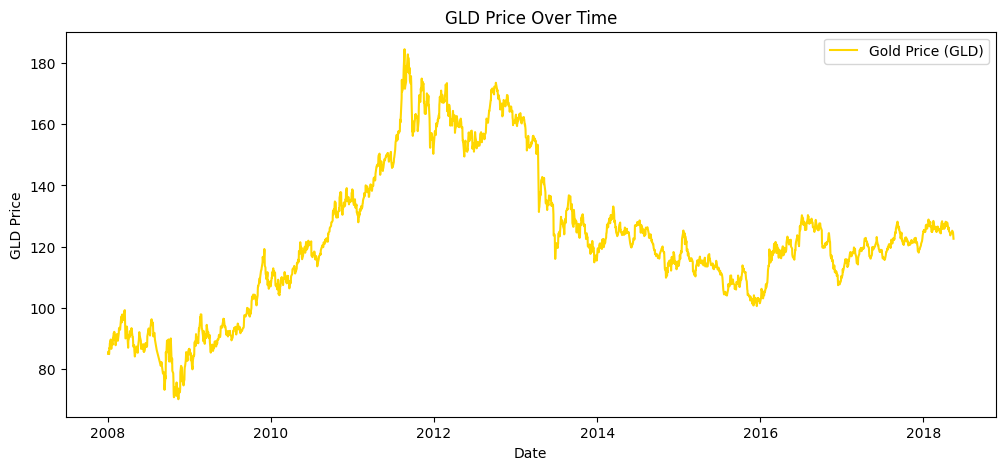

In [31]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['GLD'], label='Gold Price (GLD)',color="Gold")
plt.xlabel("Date")
plt.ylabel("GLD Price")
plt.title("GLD Price Over Time")
plt.legend()
plt.show()


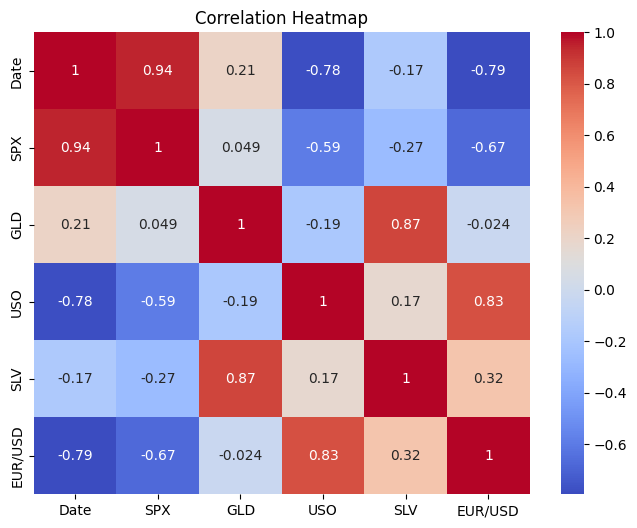

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [33]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)


In [34]:
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'GLD_lag_{lag}'] = df['GLD'].shift(lag)


In [35]:
df.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD,year,month,day,dayofweek,is_month_start,is_month_end,GLD_lag_1,GLD_lag_2,GLD_lag_3,GLD_lag_7,GLD_lag_14,GLD_lag_30
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692,2008,1,2,2,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491,2008,1,3,3,0,0,84.860001,NaN,NaN,NaN,NaN,NaN
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492,2008,1,4,4,0,0,85.570000,84.860001,NaN,NaN,NaN,NaN
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299,2008,1,7,0,0,0,85.129997,85.570000,84.860001,NaN,NaN,NaN
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099,2008,1,8,1,0,0,84.769997,85.129997,85.570000,NaN,NaN,NaN


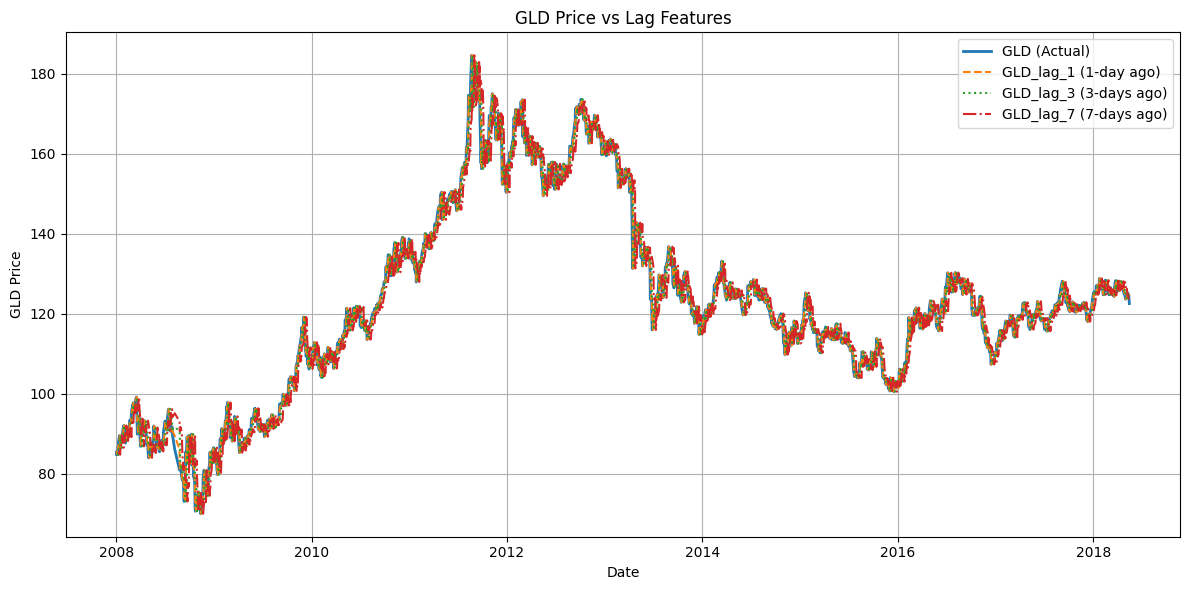

In [36]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['GLD'], label='GLD (Actual)', linewidth=2)
plt.plot(df['Date'], df['GLD_lag_1'], label='GLD_lag_1 (1-day ago)', linestyle='dashed')
plt.plot(df['Date'], df['GLD_lag_3'], label='GLD_lag_3 (3-days ago)', linestyle='dotted')
plt.plot(df['Date'], df['GLD_lag_7'], label='GLD_lag_7 (7-days ago)', linestyle='dashdot')
plt.title("GLD Price vs Lag Features")
plt.xlabel("Date")
plt.ylabel("GLD Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
for window in [3, 7, 14, 30]:
    df[f'GLD_roll_mean_{window}'] = df['GLD'].shift(1).rolling(window=window, min_periods=1).mean()


In [38]:
df = df.dropna().reset_index(drop=True)


In [39]:
df.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD,year,month,day,dayofweek,...,GLD_lag_1,GLD_lag_2,GLD_lag_3,GLD_lag_7,GLD_lag_14,GLD_lag_30,GLD_roll_mean_3,GLD_roll_mean_7,GLD_roll_mean_14,GLD_roll_mean_30
0,2008-02-14,1348.859985,89.709999,75.760002,17.087000,1.464408,2008,2,14,3,...,89.440002,89.330002,91.330002,87.680000,90.300003,84.860001,90.033335,89.654286,90.192143,88.582333
1,2008-02-15,1349.989990,89.150002,75.930000,16.952000,1.467610,2008,2,15,4,...,89.709999,89.440002,89.330002,88.949997,91.750000,85.570000,89.493334,89.944286,90.150000,88.744000
2,2008-02-19,1348.780029,91.580002,78.809998,17.378000,1.472993,2008,2,19,1,...,89.150002,89.709999,89.440002,89.849998,91.150002,85.129997,89.433334,89.972858,89.964286,88.863333
3,2008-02-20,1360.030029,93.239998,79.320000,17.700001,1.472299,2008,2,20,2,...,91.580002,89.150002,89.709999,91.000000,92.059998,84.769997,90.146668,90.220001,89.995000,89.078333
4,2008-02-21,1342.530029,93.250000,77.330002,17.695999,1.481503,2008,2,21,3,...,93.239998,91.580002,89.150002,91.330002,91.400002,86.779999,91.323334,90.540001,90.079286,89.360667


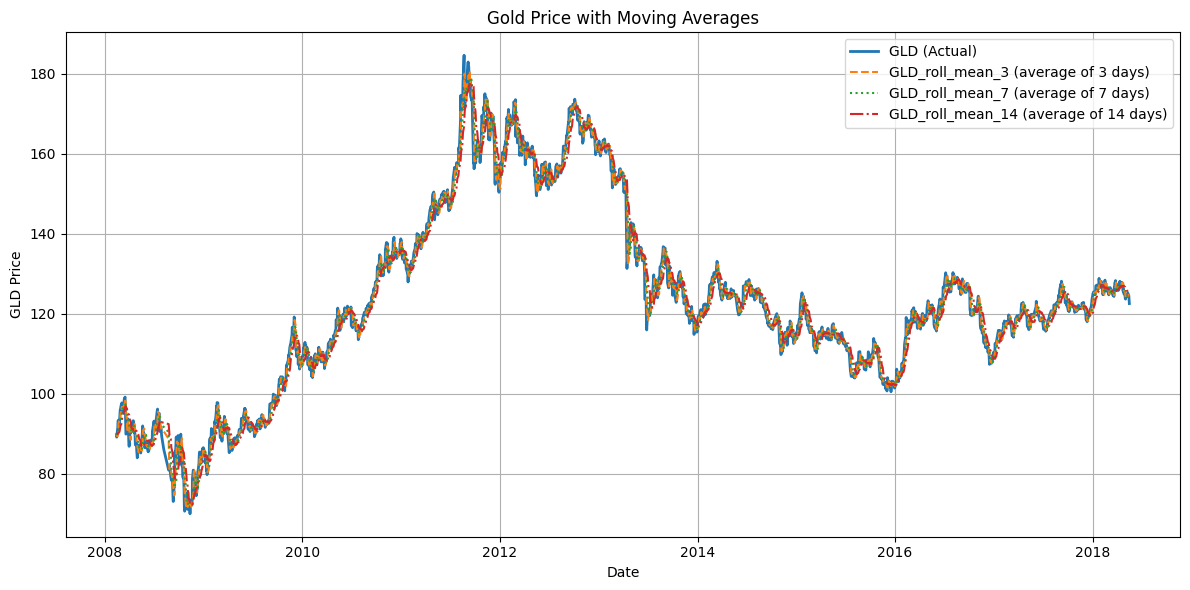

In [40]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['GLD'], label='GLD (Actual)', linewidth=2)
plt.plot(df['Date'], df['GLD_roll_mean_3'], label='GLD_roll_mean_3 (average of 3 days)', linestyle='dashed')
plt.plot(df['Date'], df['GLD_roll_mean_7'], label='GLD_roll_mean_7 (average of 7 days)', linestyle='dotted')
plt.plot(df['Date'], df['GLD_roll_mean_14'], label='GLD_roll_mean_14 (average of 14 days)', linestyle='dashdot')
plt.title("Gold Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("GLD Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
target = 'GLD'
drop_cols = ['Date', target]
X = df.drop(columns=drop_cols)
y = df[target]

In [42]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (1808, 20)  Test shape: (452, 20)


In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200,random_state=42)
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"model": model, "mae": mae, "mse":mse, "r2": r2, "preds": preds}


In [45]:
res_df = pd.DataFrame([
    {"Model": name, "MAE": r["mae"], "MSE": r["mse"], "R2": r["r2"]}
    for name, r in results.items()
])
print("\n📊 Model Performance:\n", res_df.sort_values("MSE"))


📊 Model Performance:
               Model       MAE       MSE        R2
0  LinearRegression  0.760823  1.040651  0.955965
1      RandomForest  1.042996  1.747580  0.926051
3           XGBoost  1.490284  3.281175  0.861158
2  GradientBoosting  1.596548  3.719737  0.842600


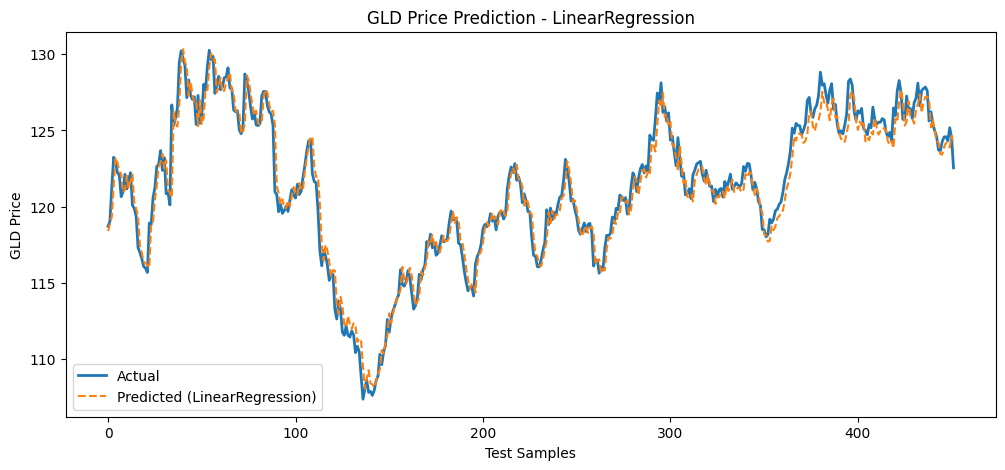

In [46]:
best_model_name = res_df.sort_values("MSE").iloc[0]["Model"]
best_preds = results[best_model_name]["preds"]

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(best_preds, label=f'Predicted ({best_model_name})', linestyle='dashed')
plt.title(f"GLD Price Prediction - {best_model_name}")
plt.xlabel("Test Samples")
plt.ylabel("GLD Price")
plt.legend()
plt.show()


 Best Tree-Based Model: RandomForest


,Feature,Importance
10,GLD_lag_1,0.854001
16,GLD_roll_mean_3,0.110813
11,GLD_lag_2,0.014314
17,GLD_roll_mean_7,0.011001
2,SLV,0.005904


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30340\4008452505.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(15), x="Importance", y="Feature", palette="viridis")


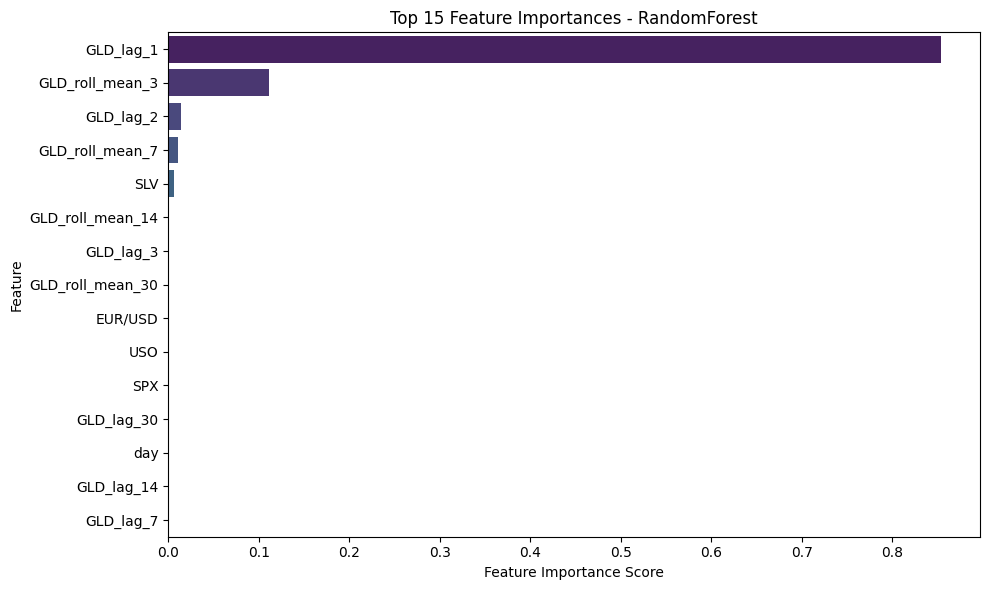

In [47]:
# tree_models = ["RandomForest", "GradientBoosting", "XGBoost"]

# if tree_models :
#     tree_df = res_df[res_df["Model"].isin(tree_models)].sort_values("MSE")
#     best_tree_model_name = tree_df.iloc[0]["Model"]
#     if best_tree_model_name in ["RandomForest", "GradientBoosting", "XGBoost"]:
#         importances = results[best_tree_model_name]["model"].feature_importances_
#         fi_df = pd.DataFrame({
#             "Feature": X.columns,
#             "Importance": importances
#         }).sort_values("Importance", ascending=False)
#         display(fi_df.head())
#         plt.figure(figsize=(10,6))
#         sns.barplot(data=fi_df.head(15), x="Importance", y="Feature")
#         plt.title(f"Top 15 Feature Importances - {best_tree_model_name}")
#         plt.xlabel("Feature Importance Score")
#         plt.ylabel("Feature")
#         plt.tight_layout()
#         plt.show()

tree_models = ["RandomForest", "GradientBoosting", "XGBoost"]
available_trees = [m for m in tree_models if m in results]
if available_trees:
    tree_df = res_df[res_df["Model"].isin(available_trees)].sort_values("MSE")
    best_tree_model_name = tree_df.iloc[0]["Model"]

    print(f"\n Best Tree-Based Model: {best_tree_model_name}")
    model = results[best_tree_model_name]["model"]

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        fi_df = pd.DataFrame({
            "Feature": X.columns,
            "Importance": importances
        }).sort_values("Importance", ascending=False)

        display(fi_df.head())

        plt.figure(figsize=(10,6))
        sns.barplot(data=fi_df.head(15), x="Importance", y="Feature", palette="viridis")
        plt.title(f"Top 15 Feature Importances - {best_tree_model_name}")
        plt.xlabel("Feature Importance Score")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()
    

In [48]:
pred_df = X_test.copy()
pred_df['Date'] = df.loc[X_test.index, 'Date']
pred_df['Actual_GLD'] = y_test.values
pred_df['Predicted_GLD'] = best_preds
pred_df.to_csv("gld_price_predictions.csv", index=False)
print("✅ Predictions saved to 'gld_price_predictions.csv'")

✅ Predictions saved to 'gld_price_predictions.csv'


In [49]:
import joblib
joblib.dump(results[best_model_name]["model"], f"gld_model_{best_model_name}.pkl")
print(f"✅ Best model '{best_model_name}' saved successfully!")

✅ Best model 'LinearRegression' saved successfully!
